# How do emissions in conflict areas of the world (Ukraine, Palestine and Iran) compare globally?

## data used: global co2 data from our world in data containing annual co2 emissions from every country
### link: https://github.com/owid/co2-data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

## loading data

In [5]:
df = pd.read_csv('owid-co2-data.csv')
 
# Exclude aggregate regions (rows without an iso_code are continents/world totals)
df_countries = df[df['iso_code'].notna() & (df['iso_code'] != '')].copy()

## finding average co2 emissions per country

In [15]:
avg_co2 = (
    df_countries.groupby('country')['co2']
    .mean()
    .dropna()
    .sort_values(ascending=False)
)
 
top5 = avg_co2.head(5)
print("=== Top 5 Countries by Average CO2 Emissions (million tonnes) ===")
for i, (country, val) in enumerate(top5.items(), 1):
    print(f"  {i}. {country}: {val:,.2f} Mt")
 
# Check whether our focus countries are already in the top 5
focus_countries = ['Palestine', 'Ukraine', 'Iran']
missing = [c for c in focus_countries if c not in top5.index]
 
if missing:
    print("\n=== Focus Countries ===")
    for country in missing:
        val = avg_co2.get(country, None)
        rank = avg_co2.rank(ascending=False).get(country, None)
        if val is not None:
            print(f"  {country}: {val:,.2f} Mt  (ranked #{int(rank)} globally)")
        else:
            print(f"  {country}: no data available")
 

=== Top 5 Countries by Average CO2 Emissions (million tonnes) ===
  1. China: 2,415.99 Mt
  2. United States: 1,932.74 Mt
  3. Russia: 709.87 Mt
  4. Japan: 443.39 Mt
  5. India: 423.54 Mt

=== Focus Countries ===
  Palestine: 2.23 Mt  (ranked #130 globally)
  Ukraine: 180.56 Mt  (ranked #11 globally)
  Iran: 189.66 Mt  (ranked #9 globally)


## plotting emissions for focus countries

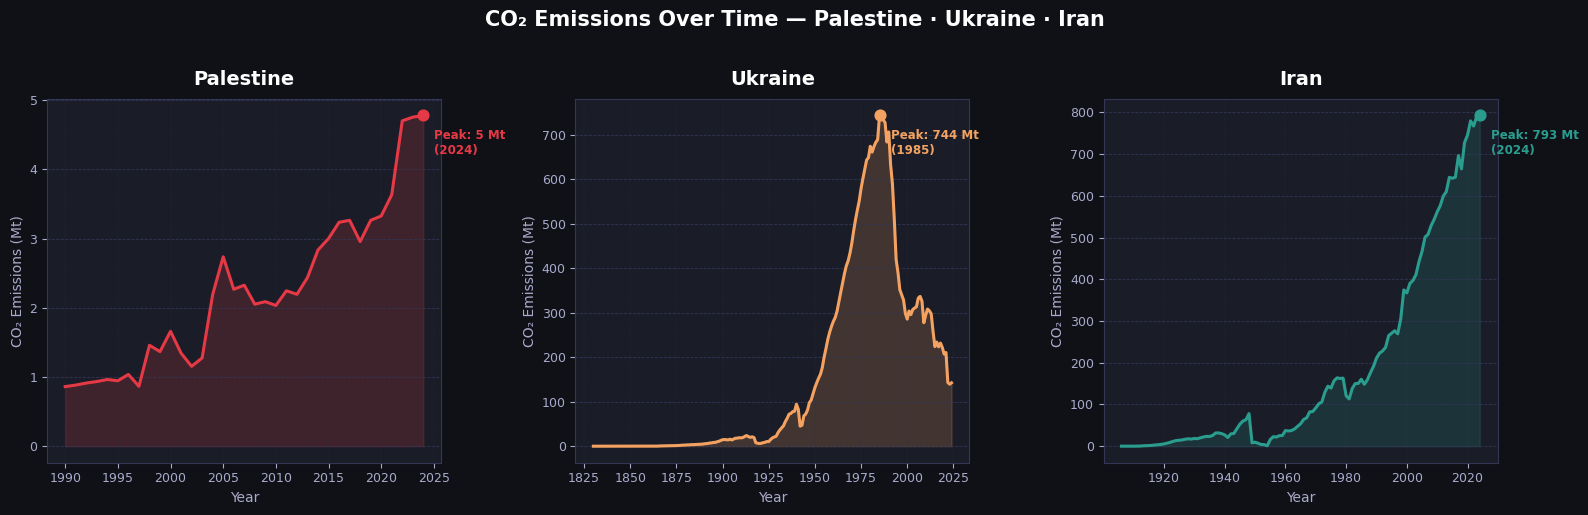

In [13]:

PALETTE = {
    'Palestine': '#E63946',
    'Ukraine':   '#F4A261',
    'Iran':      '#2A9D8F',
}
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
 
for ax, country in zip(axes, focus_countries):
    color = PALETTE[country]
    data = df_countries[df_countries['country'] == country][['year', 'co2']].dropna()
 
    ax.set_facecolor('#1a1d27')
    for spine in ax.spines.values():
        spine.set_color('#333655')
 
    # Shaded area under line
    ax.fill_between(data['year'], data['co2'], alpha=0.18, color=color)
 
    # Main line
    ax.plot(data['year'], data['co2'], color=color, linewidth=2.2, zorder=3)
 
    # Highlight max point
    peak_idx = data['co2'].idxmax()
    peak_year = data.loc[peak_idx, 'year']
    peak_val  = data.loc[peak_idx, 'co2']
    ax.scatter(peak_year, peak_val, color=color, s=60, zorder=5)
    ax.annotate(
        f"Peak: {peak_val:,.0f} Mt\n({int(peak_year)})",
        xy=(peak_year, peak_val),
        xytext=(8, -28),
        textcoords='offset points',
        color=color,
        fontsize=8.5,
        fontweight='bold',
    )
 
    ax.set_title(country, color='white', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Year', color='#aaaacc', fontsize=10)
    ax.set_ylabel('CO₂ Emissions (Mt)', color='#aaaacc', fontsize=10)
    ax.tick_params(colors='#aaaacc', labelsize=9)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(axis='y', color='#333655', linewidth=0.6, linestyle='--')
    ax.grid(axis='x', color='#333655', linewidth=0.3, linestyle=':')
 
fig.suptitle(
    'CO₂ Emissions Over Time — Palestine · Ukraine · Iran',
    color='white', fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()


## plotting global co2 emissions with focus countries outlined

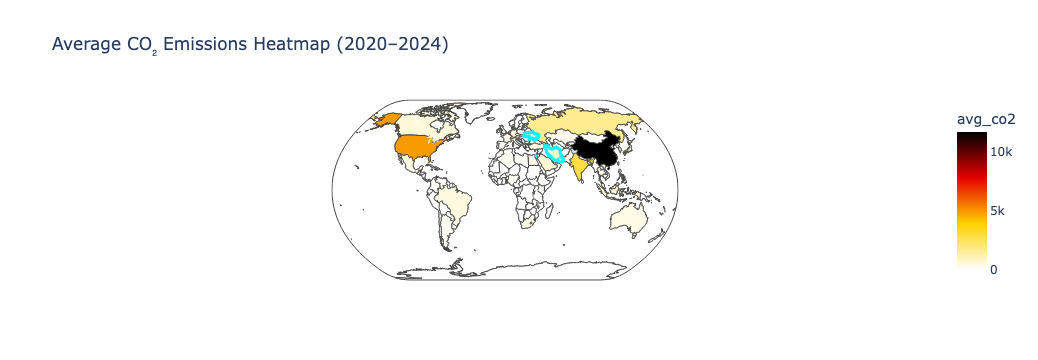

In [14]:

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv("owid-co2-data.csv")

df = df[df["iso_code"].notna()]
df = df[df["co2"].notna()]

latest_year = int(df["year"].max())
years = list(range(latest_year - 4, latest_year + 1))

recent = df[df["year"].isin(years)]

co2_avg = (
    recent.groupby(["country", "iso_code"], as_index=False)["co2"]
    .mean()
    .rename(columns={"co2": "avg_co2"})
)

fig = px.choropleth(
    co2_avg,
    locations="iso_code",
    color="avg_co2",
    hover_name="country",
    color_continuous_scale="Hot_r",
    projection="natural earth",
    title=f"Average CO₂ Emissions Heatmap ({years[0]}–{years[-1]})",
)

highlighted = {
    "Ukraine": "UKR",
    "Iran": "IRN",
    "Palestine": "PSE",
}

for name, iso in highlighted.items():
    fig.add_trace(
        go.Choropleth(
            locations=[iso],
            z=[1],
            showscale=False,
            colorscale=[[0, "rgba(0,0,0,0)"], [1, "rgba(0,0,0,0)"]],
            marker_line_color="cyan",
            marker_line_width=3,
            hovertext=[name],
            hoverinfo="text",
        )
    )

fig.show()